# Water potability using Light Gradient Boosting 

### Sections in this Notebook:

**1. Loading Dependencies and Data**

**2. Data Visualization and Feature Selection**

**3. Model Evaluation**

## 1. Loading Dependencies and Data

In [1]:
import numpy as np
import pandas as pd
import os
import re
import warnings

In [2]:
train=pd.read_csv("/kaggle/input/water-potability/water_potability.csv")
train

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1


## 2. Data Visualization and Feature Selection

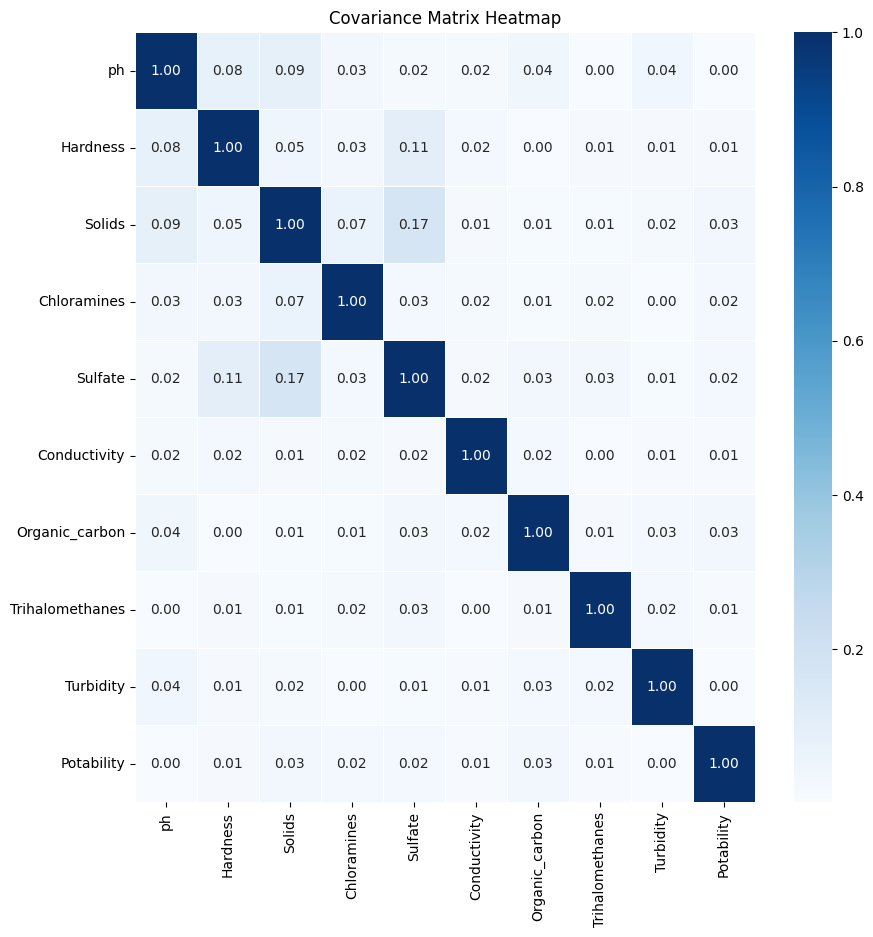

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
trainup = pd.DataFrame(scaler.fit_transform(train), columns=train.columns)
cov_matrix = abs(trainup.cov())
plt.figure(figsize=(10, 10))
sns.heatmap(cov_matrix, annot=True, cmap='Blues', fmt='.2f', linewidths=.5)
plt.title('Covariance Matrix Heatmap')
plt.show()

In [4]:
X_train=train.drop(['ph', 'Turbidity' ], axis=1)
X_train=train.drop(['Potability'], axis=1)
Y_train=train['Potability']
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)

## 3. Model Evaluation

In [5]:
import lightgbm as lgb
from sklearn.model_selection import KFold, cross_val_score
model = lgb.LGBMClassifier(verbose=-1)
model.fit(X_train, Y_train)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_val_score(model, X_train, Y_train, cv=kf, scoring='accuracy')
accuracy_values = cv_results
average_accuracy = cv_results.mean()

print("Accuracy for each fold:", accuracy_values)
print("Average Accuracy across all folds:", average_accuracy)

Accuracy for each fold: [0.6722561  0.66717557 0.66259542 0.65648855 0.65038168]
Average Accuracy across all folds: 0.6617794637870044
